# PI-NPZ Forward Prediction

Once trained, PI-NPZ functions as a discrete-time operator $M$ mapping $\mathbf{x}(t)$ to $\mathbf{x}(t+\Delta t)$.
The operator can be applied autoregressively, where the prediction at step $i$ becomes the input for step $i+1$, enabling multi-step forecasts.
This iterative forecasting procedure is defined by
\begin{equation}
\mathbf{x}_{i+1} = M_{i+1,i}(\mathbf{x}_i).
\end{equation}
Here, $M$ denotes the forecast operator (either Traditional-NPZ or PI-NPZ), with $M_{i+1,i}$ indicating the mapping from time $t_i$ to $t_{i+1}$. 

While PI-NPZ is trained to learn state transitions, this one-step training loss alone is insufficient for model selection since it reflects only local accuracy and fails to capture long-term forecasting skill.
We therefore quantified forecast accuracy using a multi-step skill score, comparing autoregressive PI-NPZ forecasts against reference trajectories from Traditional-NPZ:
\begin{equation}
S = 1 - \frac{\left| \hat{\mathbf{x}} - \mathbf{x} \right|}{\left| \mathbf{x} \right|},
\end{equation}
where $\hat{\mathbf{x}}$ denotes the PI-NPZ forecast, $\mathbf{x}$ the reference trajectory, and $|\cdot|$ indicates the element-wise absolute value.


In [ ]:
%matplotlib inline
import importlib
import subprocess
import sys

def install_and_import(package):
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"{package} not found, installing it now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    finally:
        globals()[package] = importlib.import_module(package)

# Standard library imports
import os
import time
import warnings

# Third-party imports
third_party_packages = ['numpy', 'pandas', 'matplotlib', 'scipy', 'sklearn', 'torch']

for package in third_party_packages:
    install_and_import(package)

# Specific imports from installed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import odeint
from scipy.sparse.linalg import LinearOperator, cg
from scipy.linalg import eigvals
from scipy.optimize import brentq
from numpy import linalg as LA

import torch
from torch import nn

import lightning.pytorch as pl
from pytorch_lightning import seed_everything
from torch.utils.data import DataLoader, TensorDataset
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import time
# Local imports
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn
from traditional_npz import run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import calculate_rel_error, calculate_rmse, read_and_preprocess_data


In [4]:
num_threads = torch.get_num_threads()
torch.set_num_threads(num_threads)

# CPU device
dtype = torch.float64
device = torch.device('cpu') # Smaller models/data, running on CPU

dataset_dir = 'data'
dataset_path = f'{dataset_dir}/npz_training_set.csv'
x, u, nd_ntot = read_and_preprocess_data(f"../{dataset_path}",device='cpu')


Reading CSV file...
CSV file read successfully


In [5]:
# Load Model Checkpoint
checkpoint_dir = 'model_checkpoints'
model_ckpt_name = 'pi_npz_final.ckpt'
checkpoint_path = f"../{checkpoint_dir}/{model_ckpt_name}"

# Non-dimensionalization
t_scale = 1.0
alpha_tilde = 1.2164 * t_scale
beta_tilde = 1.2795 * nd_ntot
b_tilde = 0.1 * t_scale
c_tilde = 0.2 * t_scale
e_tilde = 0.5 * t_scale * nd_ntot
f_tilde = 0.5 * t_scale * nd_ntot
# Define parameters for GELU model
params_dict = {
'alpha_tilde': torch.tensor([alpha_tilde], dtype=dtype),
'beta_tilde': torch.tensor([beta_tilde], dtype=dtype),
'b_tilde': torch.tensor([b_tilde], dtype=dtype),
'c_tilde': torch.tensor([c_tilde], dtype=dtype),
'e_tilde': torch.tensor([e_tilde], dtype=dtype),
'f_tilde': torch.tensor([f_tilde], dtype=dtype),
}

learning_rate = 0.0006
num_layers = 5
num_neurons = 384
activation_function = nn.GELU

# Step 1: Load the checkpoint manually
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# Step 2: Reconstruct the model using the same init args
pi_npz_model = PhysicsInformedNN(
    DNN=DNN,
    num_layers=num_layers,
    num_neurons=num_neurons,
    activation_function=activation_function,
    params_dict=params_dict,
    lambda_u=1,
    lambda_f=1,
    learning_rate=learning_rate,
    dtype=dtype
)

# Step 3: Load the model weights from the checkpoint
pi_npz_model.load_state_dict(checkpoint["state_dict"])

# Step 4: Optional – move to float64
pi_npz_model = pi_npz_model.to(torch.float64)


In [6]:
# List of coefficients to extract and back-transform
coefficients_to_print = ["alpha_tilde", "beta_tilde", "b_tilde", "c_tilde", "e_tilde", "f_tilde"]

def get_back_transformed_coefficients(model, t_scale, nd_ntot):
    coefficients_dict = {}
    for name, value in model.named_buffers():
        if name in coefficients_to_print:
            clean_name = name.replace("_tilde", "")
            if name == 'alpha_tilde':
                original_value = (value.clone().detach() / t_scale).reshape(1)
            elif name == 'beta_tilde':
                original_value = (value.clone().detach() / nd_ntot).reshape(1)
            elif name == 'b_tilde':
                original_value = (value.clone().detach() / t_scale).reshape(1)
            elif name == 'c_tilde':
                original_value = (value.clone().detach() / t_scale).reshape(1)
            elif name == 'e_tilde':
                original_value = (value.clone().detach() / (t_scale * nd_ntot)).reshape(1)
            elif name == 'f_tilde':
                original_value = (value.clone().detach() / (t_scale * nd_ntot)).reshape(1)
            coefficients_dict[clean_name] = original_value
    return coefficients_dict


# Get and print coefficients for GELU model
print("Initial Model Coefficients:")
coefficients_dict = get_back_transformed_coefficients(pi_npz_model, t_scale, nd_ntot)
for name, value in coefficients_dict.items():
    print(f"{name}: {value.item()}")

# === Printouts ===
print("=== Trainable Parameters ===")
for name, param in pi_npz_model.named_parameters():
    print(name, param.shape, "requires_grad =", param.requires_grad)

print("\n=== Frozen Ecological Coefficients ===")
coefficients_dict = get_back_transformed_coefficients(pi_npz_model, t_scale, nd_ntot)
for name, value in coefficients_dict.items():
    print(f"{name}: {value.item()}")

Initial Model Coefficients:
alpha: 1.2164000272750854
beta: 1.2795000076293945
b: 0.10000000149011612
c: 0.20000000298023224
e: 0.5
f: 0.5
=== Trainable Parameters ===
dnn.layers.layer_0.weight torch.Size([384, 4]) requires_grad = True
dnn.layers.layer_0.bias torch.Size([384]) requires_grad = True
dnn.layers.layer_1.weight torch.Size([384, 384]) requires_grad = True
dnn.layers.layer_1.bias torch.Size([384]) requires_grad = True
dnn.layers.layer_2.weight torch.Size([384, 384]) requires_grad = True
dnn.layers.layer_2.bias torch.Size([384]) requires_grad = True
dnn.layers.layer_3.weight torch.Size([384, 384]) requires_grad = True
dnn.layers.layer_3.bias torch.Size([384]) requires_grad = True
dnn.layers.layer_4.weight torch.Size([384, 384]) requires_grad = True
dnn.layers.layer_4.bias torch.Size([384]) requires_grad = True
dnn.layers.layer_5.weight torch.Size([3, 384]) requires_grad = True
dnn.layers.layer_5.bias torch.Size([3]) requires_grad = True

=== Frozen Ecological Coefficients ===


## Forward Modeling with PINN

In [7]:
total_days = 7 # / 24

intervals_per_day = 24 * 2 * 3 # 10 minute intervals

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]

In [8]:
# Step 5: Convert to torch tensor
# # Load dataset
test_set_initial_states = pd.read_csv("../data/npz_test_set.csv", index_col=False)
test_set_initial_states = test_set_initial_states[['N', 'P', 'Z']].values

test_set_initial_states_tensor = torch.tensor(test_set_initial_states, device=device, dtype=dtype)

# Confirm
print(f"Selected {len(test_set_initial_states_tensor)} samples in [1.8, 2.2] with all components >= 0.1")
print(f"New mean total N: {test_set_initial_states_tensor.sum(dim=1).mean().item():.4f}")


Selected 10000 samples in [1.8, 2.2] with all components >= 0.1
New mean total N: 2.0501


In [9]:
from joblib import Parallel, delayed
import datetime
# # Wrap the callable for each job
def run_forward_pinn_single(x0, nd_ntot, times):
    # reconstruct or load model inside worker if needed
    global pi_npz_model
    pred = forward_pinn(pi_npz_model, x0, nd_ntot, times).detach().numpy()
    return pred

# Run in parallel
n_jobs = 6
start_time = time.time()
print(f"Start time: {start_time}")
dt = datetime.datetime.fromtimestamp(start_time)  # local time
dt_utc = datetime.datetime.fromtimestamp(start_time)  # UTC

print("Local time:", dt)
print("UTC time:", dt_utc)
test_forward_predictions_list = Parallel(n_jobs=n_jobs)(
    delayed(run_forward_pinn_single)(x0, nd_ntot, times)
    for x0 in test_set_initial_states_tensor
)
end_time = time.time()
pinn_prediction_loop_time = end_time - start_time
print(f"Running time: {pinn_prediction_loop_time:.2f} sec ({pinn_prediction_loop_time/60:.2f} min)")


Start time: 1760836358.916319
Local time: 2025-10-18 15:12:38.916319
UTC time: 2025-10-18 15:12:38.916319
Running time: 473.83 sec (7.90 min)


In [10]:
# Flatten all predictions into one big array
all_preds = np.concatenate(test_forward_predictions_list, axis=0)

# Check if any values are negative
has_negatives = np.any(all_preds < 0)
print("Contains negative values:", has_negatives)

# Optional: count them
num_negatives = np.sum(all_preds < 0)
print("Number of negative values:", num_negatives)


Contains negative values: False
Number of negative values: 0


In [11]:
neg_ic_indices = []
neg_counts = []

for i, traj in enumerate(test_forward_predictions_list):
    if np.any(traj < 0):
        neg_ic_indices.append(i)
        neg_counts.append(np.sum(traj < 0))

print("Number of ICs with negatives:", len(neg_ic_indices))
for idx, count in zip(neg_ic_indices, neg_counts):
    print(f"IC #{idx} has {count} negative values")

for idx in neg_ic_indices:
    print(f"IC {idx}: {test_set_initial_conditions[idx].cpu().numpy()}")


Number of ICs with negatives: 0


In [13]:
# Define system parameters
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# Define time parameters
tstart = 0
minutes_per_step = 10
minutes_per_hour = 60
hours_per_day = 24
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, total_days + dt, dt)

# Define training time intervals
intervals_per_day = 24 * 2 * 3  # Half-hour intervals
times_train = np.arange(0, total_days + 1 / intervals_per_day, 1 / intervals_per_day)
if times_train[-1] > total_days:
    times_train = times_train[:-1]

# Worker function
def rk4_worker(ic):
    N0, P0, Z0 = ic
    xt_result = run_rk4_for_initial_conditions(N0, P0, Z0, t, phi)
    xt_array = np.column_stack((t, xt_result[:, 0], xt_result[:, 1], xt_result[:, 2]))
    matching_indices = np.searchsorted(t, times_train)
    xt_matching_rows = xt_array[matching_indices]
    return xt_matching_rows[:, 1:]  # Only N, P, Z columns

# Run in parallel
start_time = time.time()
test_xt_results = Parallel(n_jobs=-1, backend="loky")(
    delayed(rk4_worker)(ic) for ic in test_set_initial_states_tensor.numpy()
)
end_time = time.time()

rk4_prediction_loop_time = end_time - start_time
print(f"Running time: {rk4_prediction_loop_time:.2f} seconds")


Running time: 39.19 seconds


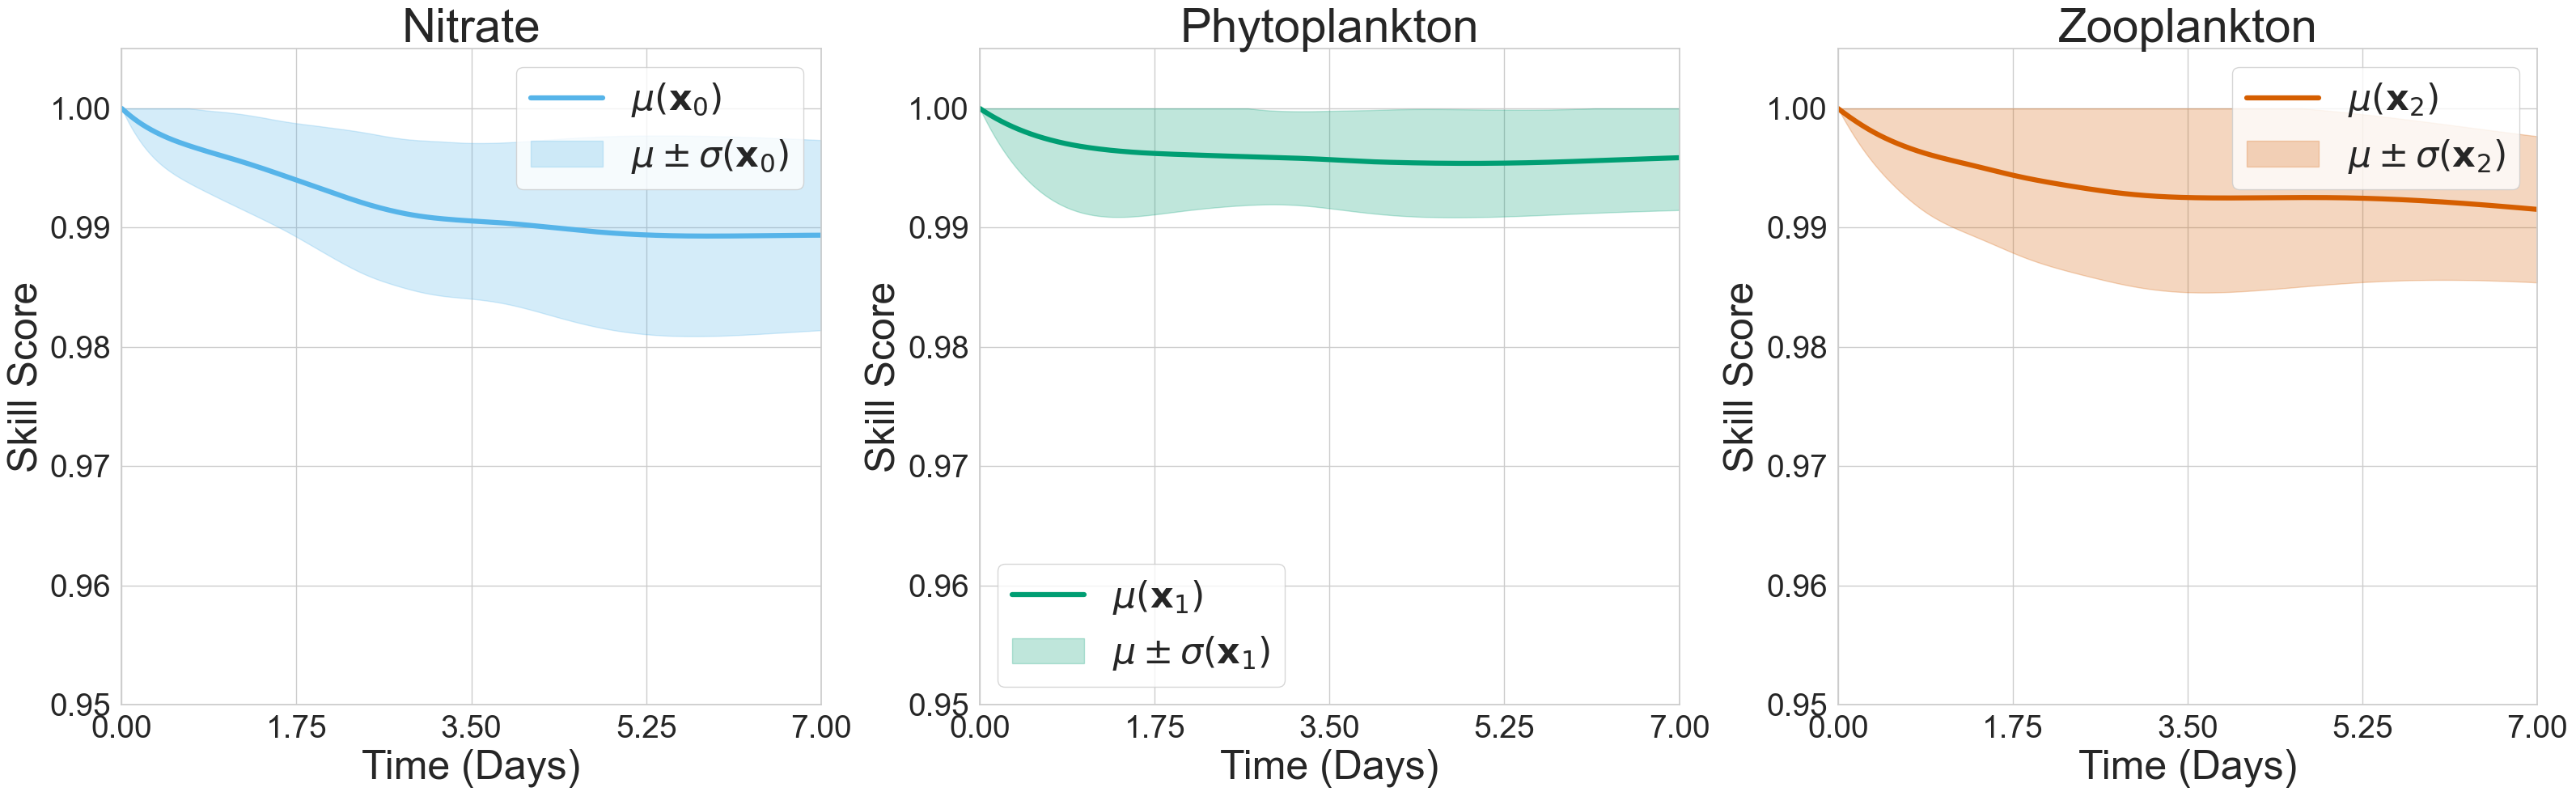

In [14]:
test_forward_actuals = [np.array(gt) for gt in test_xt_results]  # No slicing!

test_forward_preds = np.array(test_forward_predictions_list)  # Shape: [N, T, 3]
test_forward_truths = np.array(test_forward_actuals)          # Shape: [N, T, 3]


test_skill_scores = 1 - (np.abs(test_forward_preds - test_forward_truths) / np.abs(test_forward_truths))

# Now aggregate: mean and std over all trajectories (axis=0)
# Resulting shapes: (num_time_steps, num_vars)
test_skill_mean = np.nanmean(test_skill_scores, axis=0)
test_skill_std = np.nanstd(test_skill_scores, axis=0)

# Transpose to: skill_mean[var][t]
test_skill_mean = test_skill_mean.T  # Shape: (3, num_time_steps)
test_skill_std = test_skill_std.T    # Shape: (3, num_time_steps)

def plot_with_shade(ax, y_vals, y_stds, title, y_label, ylim, alpha, color, var_label, min_val=0.0):
    # Clip lower and upper bounds
    lower = np.clip(np.array(y_vals) - np.array(y_stds), min_val, None)
    upper = np.clip(np.array(y_vals) + np.array(y_stds), None, 1.0)

    ax.plot(times, y_vals, label=fr"$\mu({var_label})$", color=color, linewidth=LINE_WIDTH)
    ax.fill_between(times, lower, upper, color=color, alpha=alpha, label=fr"$\mu \pm \sigma({var_label})$")
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xlabel(x_axis_label, fontsize=LABEL_SIZE)
    ax.set_ylabel(y_label, fontsize=LABEL_SIZE)
    ax.set_ylim(*ylim)
    ax.set_xlim(0, 7)
    ax.set_xticks(np.linspace(0, 7, num_ticks))
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    ax.legend(fontsize=LABEL_SIZE - 4)

# === Style and font sizes ===
sns.set(style="whitegrid")
TITLE_SIZE = 42
LABEL_SIZE = 36
TICK_SIZE = 28
LINE_WIDTH = 4.5
ALPHA_NUM = 0.25
# === Data and Layout Settings ===
gelu_color = 'blue'
y_lim_rmse = 0.01
x_axis_label = 'Time (Days)'
y_axis_rmse_label = 'RMSE'
num_ticks = 5
tick_positions = np.linspace(times.min(), times.max(), num_ticks)

# === Colorblind friendly ===
# color_n, color_p, color_z = "#bc5d41", "#84a955", "#965da7"
color_n, color_p, color_z  = "#56B4E9", "#009E73", "#D55E00"
# === Skill Score axis label and y-limit ===
y_axis_skill_label = 'Skill Score'
y_lim_skill = (0.95, 1.005)  # Enforces minimum at 0

# === Create figure ===
fig, axs = plt.subplots(1, 3, figsize=(32, 10), sharex=False, sharey=False)

# === Plot Skill Score for N, P, Z ===
plot_with_shade(
    axs[0],
    test_skill_mean[0],
    test_skill_std[0],
    'Nitrate',
    y_axis_skill_label,
    y_lim_skill,
    ALPHA_NUM,
    color_n,
    var_label=r"\mathbf{x}_0"
)

plot_with_shade(
    axs[1],
    test_skill_mean[1],
    test_skill_std[1],
    'Phytoplankton',
    y_axis_skill_label,
    y_lim_skill,
    ALPHA_NUM,
    color_p,
    var_label=r"\mathbf{x}_1"
)

plot_with_shade(
    axs[2],
    test_skill_mean[2],
    test_skill_std[2],
    'Zooplankton',
    y_axis_skill_label,
    y_lim_skill,
    ALPHA_NUM,
    color_z,
    var_label=r"\mathbf{x}_2"
)

plt.tight_layout()
plt.show()


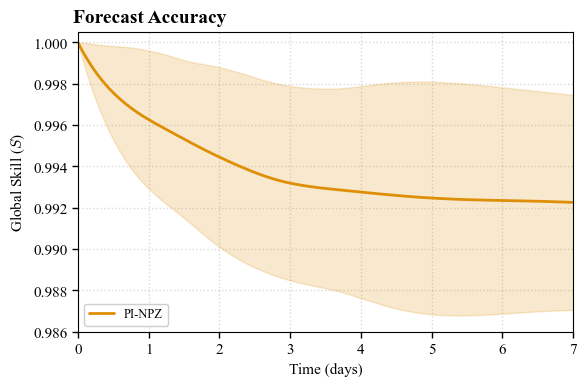

Final skill score: 0.9923 ± 0.0052
Minimum skill score: 0.9923 at day 7.00


In [ ]:
# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# Axis and tick styling
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'


# Color scheme
skill_color = "#DE8F05" #"#333333"

STEP_MINUTES = 10
T_steps = 1000
N_trajectories = test_set_initial_states.shape[0]

# === Skill calculations ===
total_skill_per_trajectory = np.nanmean(test_skill_scores, axis=2)  # shape (N, T)
total_skill_mean = np.nanmean(total_skill_per_trajectory, axis=0)
total_skill_std = np.nanstd(total_skill_per_trajectory, axis=0)

# Time vector
times = np.linspace(0, 7, total_skill_mean.shape[0])

# Bounds for shading
lower = np.clip(total_skill_mean - total_skill_std, 0.0, None)
upper = np.minimum(total_skill_mean + total_skill_std, 1.0)

# === Single-panel figure ===
fig, ax = plt.subplots(figsize=(6, 4))  # Keep your original size

# Plot mean and uncertainty
line = ax.plot(times, total_skill_mean, color=skill_color, linewidth=2, label='PI-NPZ')
shade = ax.fill_between(times, lower, upper, color=skill_color, alpha=0.2)#, label='±1σ')

# Optional: Add 99% threshold line if relevant
# ax.axhline(0.99, color=threshold_99_color, linestyle='--', linewidth=1, alpha=0.7, label='τ = 0.99')

# Labels with appropriate font sizes
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Global Skill ($S$)", fontsize=11)  # More specific label

# Set axis limits
ax.set_xlim(0, 7)
ax.set_ylim(0.986, 1.0005)

# Format y-axis to show 3 decimal places for clarity
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Grid (subtle)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')
# ax.minorticks_on()
ax.tick_params(direction='out', length=4, width=1, color='black')

# Add legend (ESSENTIAL for publication)
ax.legend(loc='lower left', fontsize=9, framealpha=0.95)

# Title - keeping as in original
ax.text(-0.01, 1.02, 'Forecast Accuracy', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='left', va='bottom')

plt.tight_layout()

# === Save ===
base_path = "../figures/"
file_base = f"forecast_skill"

# Save as vector format (PDF) for publication and PNG for review
for ext in ["pdf"]:
    if ext == "png":
        dpi = 600  # High DPI for raster
    else:
        dpi = None  # Vector formats don't need DPI
    plt.savefig(f"{base_path}{file_base}.{ext}", 
                dpi=dpi, 
                bbox_inches='tight', 
                pad_inches=0.02,
                format=ext)

plt.show()

# === Print Summary (update to match axis notation) ===
print(f"Final skill score: {total_skill_mean[-1]:.4f} ± {total_skill_std[-1]:.4f}")
print(f"Minimum skill score: {total_skill_mean.min():.4f} at day {times[total_skill_mean.argmin()]:.2f}")


In [18]:
# --- Summary statistics ---
# 1. Per-variable averages across time
skill_mean_over_time = np.nanmean(test_skill_mean, axis=1)
skill_std_over_time = np.nanmean(test_skill_std, axis=1)

# 2. Global averages (all variables, all time)
global_skill_mean = np.nanmean(test_skill_mean)
global_skill_std = np.nanmean(test_skill_std)

# 3. Per-trajectory averages
traj_skill_means = np.nanmean(test_skill_scores, axis=(1,2))
traj_skill_stds = np.nanstd(test_skill_scores, axis=(1,2))

# 4. Early vs late forecast (first/last 50 timesteps)
early_skill = np.nanmean(test_skill_mean[:, :50], axis=1)
late_skill = np.nanmean(test_skill_mean[:, -50:], axis=1)

# --- Print nicely ---
summary_df = pd.DataFrame({
    "Variable": ["N", "P", "Z"],
    "Mean Skill": skill_mean_over_time,
    "Std Skill": skill_std_over_time,
    "Early Skill (first 50 steps)": early_skill,
    "Late Skill (last 50 steps)": late_skill
})

print("\n=== Skill Summary Per Variable ===")
print(summary_df.round(4))

print("\n=== Global Statistics ===")
print(f"Global mean skill: {global_skill_mean:.4f}")
print(f"Global std skill:  {global_skill_std:.4f}")

print("\n=== Trajectory Statistics ===")
print(f"Median trajectory skill: {np.nanmedian(traj_skill_means):.4f}")
print(f"Trajectory skill IQR:    {np.nanpercentile(traj_skill_means, 75) - np.nanpercentile(traj_skill_means, 25):.4f}")



=== Skill Summary Per Variable ===
  Variable  Mean Skill  Std Skill  Early Skill (first 50 steps)  \
0        N      0.9919     0.0062                        0.9989   
1        P      0.9961     0.0044                        0.9992   
2        Z      0.9936     0.0065                        0.9990   

   Late Skill (last 50 steps)  
0                      0.9894  
1                      0.9958  
2                      0.9917  

=== Global Statistics ===
Global mean skill: 0.9939
Global std skill:  0.0057

=== Trajectory Statistics ===
Median trajectory skill: 0.9941
Trajectory skill IQR:    0.0037
